# Delivery Time Prediction — Feature Engineering

**Input:** `train_clean.csv` / `test_clean.csv`  
**Output:** `train_features.csv` / `test_features.csv`  

**Features added:**
- `same_city` — boolean, seller and customer in same city
- `is_weekend` — boolean, order placed on Saturday or Sunday
- `same_day_approval` — boolean, order approved same day it was placed
- `distance_km` — haversine distance between seller and customer
- `product_density` — product_weight_g / volume_cm3
- `seller_mean_delivery` — mean delivery time per seller (train only, with fallback)
- `seller_pending_orders` — orders placed by same seller on the same day (proxy for load)
- Encoding of `product_category_name_english`, `customer_city`, `seller_city`

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

TARGET = 'delivery_time_days'
print('Setup complete ✓')

/Users/anas/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Setup complete ✓


---
## 1. Load cleaned data

In [5]:
train = pd.read_csv('dataset/processed/train_clean.csv')
test  = pd.read_csv('dataset/processed/test_clean.csv')

for col in ['order_purchase_timestamp', 'order_approved_at']:
    for df in (train, test):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')

Train : (83401, 16)
Test  : (14864, 15)


---
## 2. Boolean — `same_city`

In [6]:
for df in (train, test):
    df['same_city'] = (
        df['customer_city'].str.lower().str.strip() ==
        df['seller_city'].str.lower().str.strip()
    ).astype(int)

print(f'same_city rate — train : {train["same_city"].mean()*100:.1f}%')
print(f'same_city rate — test  : {test["same_city"].mean()*100:.1f}%')

same_city rate — train : 4.9%
same_city rate — test  : 6.6%


---
## 3. Boolean — `is_weekend`

In [7]:
for df in (train, test):
    df['is_weekend'] = (df['order_purchase_timestamp'].dt.dayofweek >= 5).astype(int)

print(f'is_weekend rate — train : {train["is_weekend"].mean()*100:.1f}%')
print(f'is_weekend rate — test  : {test["is_weekend"].mean()*100:.1f}%')

is_weekend rate — train : 23.0%
is_weekend rate — test  : 23.0%


---
## 4. Boolean — `same_day_approval`

In [8]:
for df in (train, test):
    df['same_day_approval'] = (
        df['order_purchase_timestamp'].dt.date ==
        df['order_approved_at'].dt.date
    ).astype(int)

print(f'same_day_approval rate — train : {train["same_day_approval"].mean()*100:.1f}%')
print(f'same_day_approval rate — test  : {test["same_day_approval"].mean()*100:.1f}%')

same_day_approval rate — train : 69.6%
same_day_approval rate — test  : 67.4%


---
## 5. Distance — haversine `distance_km`

In [9]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return R * 2 * np.arcsin(np.sqrt(a))

for df in (train, test):
    df['distance_km'] = haversine_km(
        df['customer_lat'], df['customer_lng'],
        df['seller_lat'],   df['seller_lng']
    )

print('distance_km — train:')
print(train['distance_km'].describe().round(1).to_string())

distance_km — train:
count    83401.0
mean       606.6
std        592.0
min          0.0
25%        205.9
50%        440.8
75%        802.6
max       5338.6


---
## 6. Product density — `product_density`

In [10]:
for df in (train, test):
    df['product_density'] = (
        df['product_weight_g'] / df['volume_cm3'].replace(0, np.nan)
    )
    # Fill the rare cases where volume is 0
    median_density = df['product_density'].median()
    df['product_density'].fillna(median_density, inplace=True)

print('product_density — train:')
print(train['product_density'].describe().round(4).to_string())

product_density — train:
count    83401.0000
mean         0.7576
std          0.0998
min          0.1256
25%          0.6922
50%          0.7495
75%          0.8251
max          1.7135


---
## 7. Seller aggregations

> ⚠️ Both features below are computed on the **full training set**. When running cross-validation in the modelling notebook, recompute them **inside each fold** to avoid target leakage.

### 7a. `seller_mean_delivery`

In [11]:
GLOBAL_MEAN = train[TARGET].mean()

seller_mean = (
    train.groupby('seller_id')[TARGET]
         .mean()
         .rename('seller_mean_delivery')
         .reset_index()
)

train = train.merge(seller_mean, on='seller_id', how='left')
test  = test.merge(seller_mean,  on='seller_id', how='left')

# Unseen sellers in test → fall back to global mean
train['seller_mean_delivery'].fillna(GLOBAL_MEAN, inplace=True)
test['seller_mean_delivery'].fillna(GLOBAL_MEAN,  inplace=True)

unseen = test['seller_id'].isin(train['seller_id']).eq(False).sum()
print(f'Unseen sellers in test filled with global mean: {unseen}')
print(train['seller_mean_delivery'].describe().round(2).to_string())

Unseen sellers in test filled with global mean: 1619
count    83401.00
mean        13.05
std          3.03
min          1.04
25%         11.08
50%         12.87
75%         14.74
max         47.22


### 7b. `seller_pending_orders` — orders placed by the same seller on the same calendar day

In [12]:
for df in (train, test):
    df['_purchase_date'] = df['order_purchase_timestamp'].dt.date

# Count orders per seller per day (using train only as the source of truth)
seller_daily_load = (
    train.groupby(['seller_id', '_purchase_date'])
         .size()
         .rename('seller_pending_orders')
         .reset_index()
)

train = train.merge(seller_daily_load, on=['seller_id', '_purchase_date'], how='left')
test  = test.merge(seller_daily_load,  on=['seller_id', '_purchase_date'], how='left')

# Unseen seller-day combinations → 1 (the order itself)
train['seller_pending_orders'].fillna(1, inplace=True)
test['seller_pending_orders'].fillna(1,  inplace=True)

# Drop helper column
train.drop(columns=['_purchase_date'], inplace=True)
test.drop(columns=['_purchase_date'],  inplace=True)

print('seller_pending_orders — train:')
print(train['seller_pending_orders'].describe().round(2).to_string())

seller_pending_orders — train:
count    83401.00
mean         2.60
std          3.84
min          1.00
25%          1.00
50%          1.00
75%          3.00
max         78.00


---
## 8. Categorical encoding

In [13]:
# Strategy:
# - product_category_name_english : low-medium cardinality → target encoding
#   (mean delivery time per category, computed on train only)
# - customer_city / seller_city   : high cardinality → frequency encoding
#   (number of occurrences in train; captures how major/minor a city is)

# ── Target encoding: product_category_name_english ──────────────────────────
cat_mean = (
    train.groupby('product_category_name_english')[TARGET]
         .mean()
         .rename('category_mean_delivery')
         .reset_index()
)

train = train.merge(cat_mean, on='product_category_name_english', how='left')
test  = test.merge(cat_mean,  on='product_category_name_english', how='left')

train['category_mean_delivery'].fillna(GLOBAL_MEAN, inplace=True)
test['category_mean_delivery'].fillna(GLOBAL_MEAN,  inplace=True)

# ── Frequency encoding: customer_city & seller_city ─────────────────────────
for col, new_col in [('customer_city', 'customer_city_freq'),
                     ('seller_city',   'seller_city_freq')]:
    freq = train[col].str.lower().str.strip().value_counts().rename(new_col)
    train[new_col] = train[col].str.lower().str.strip().map(freq).fillna(0).astype(int)
    test[new_col]  = test[col].str.lower().str.strip().map(freq).fillna(0).astype(int)

print('Encoding done ✓')
print(f'  category_mean_delivery  — nunique: {train["category_mean_delivery"].nunique()}')
print(f'  customer_city_freq      — range  : {train["customer_city_freq"].min()} – {train["customer_city_freq"].max()}')
print(f'  seller_city_freq        — range  : {train["seller_city_freq"].min()} – {train["seller_city_freq"].max()}')

Encoding done ✓
  category_mean_delivery  — nunique: 71
  customer_city_freq      — range  : 1 – 12680
  seller_city_freq        — range  : 1 – 20568


---
## 9. Drop raw categorical and timestamp columns

In [14]:
COLS_TO_DROP = [
    'product_category_name_english',
    'customer_city', 'seller_city',
    'order_purchase_timestamp', 'order_approved_at',
    'seller_id',
    'customer_lat', 'customer_lng',
    'seller_lat', 'seller_lng',
]

train = train.drop(columns=[c for c in COLS_TO_DROP if c in train.columns])
test  = test.drop(columns=[c for c in COLS_TO_DROP if c in test.columns])

# Align columns (test must match train features exactly, minus target)
feature_cols = [c for c in train.columns if c != TARGET]
test = test[feature_cols]

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
print(f'\nFinal features ({len(feature_cols)}):')
print(feature_cols)

Train : (83401, 16)
Test  : (14864, 15)

Final features (15):
['quantity', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'same_city', 'is_weekend', 'same_day_approval', 'distance_km', 'product_density', 'seller_mean_delivery', 'seller_pending_orders', 'category_mean_delivery', 'customer_city_freq', 'seller_city_freq']


---
## 10. Validation

In [15]:
assert train.isnull().sum().sum() == 0, 'Missing values in train!'
assert test.isnull().sum().sum()  == 0, 'Missing values in test!'
assert TARGET not in test.columns,      'Target leaking into test!'
assert set(feature_cols) == set(test.columns), 'Feature mismatch between train and test!'
assert np.isinf(train.select_dtypes(include=np.number).values).sum() == 0, 'Inf in train!'
assert np.isinf(test.select_dtypes(include=np.number).values).sum()  == 0, 'Inf in test!'

print('All validation checks passed ✓')

All validation checks passed ✓


---
## 11. Correlation matrix

FileNotFoundError: [Errno 2] No such file or directory: '../plots/correlation_matrix.png'

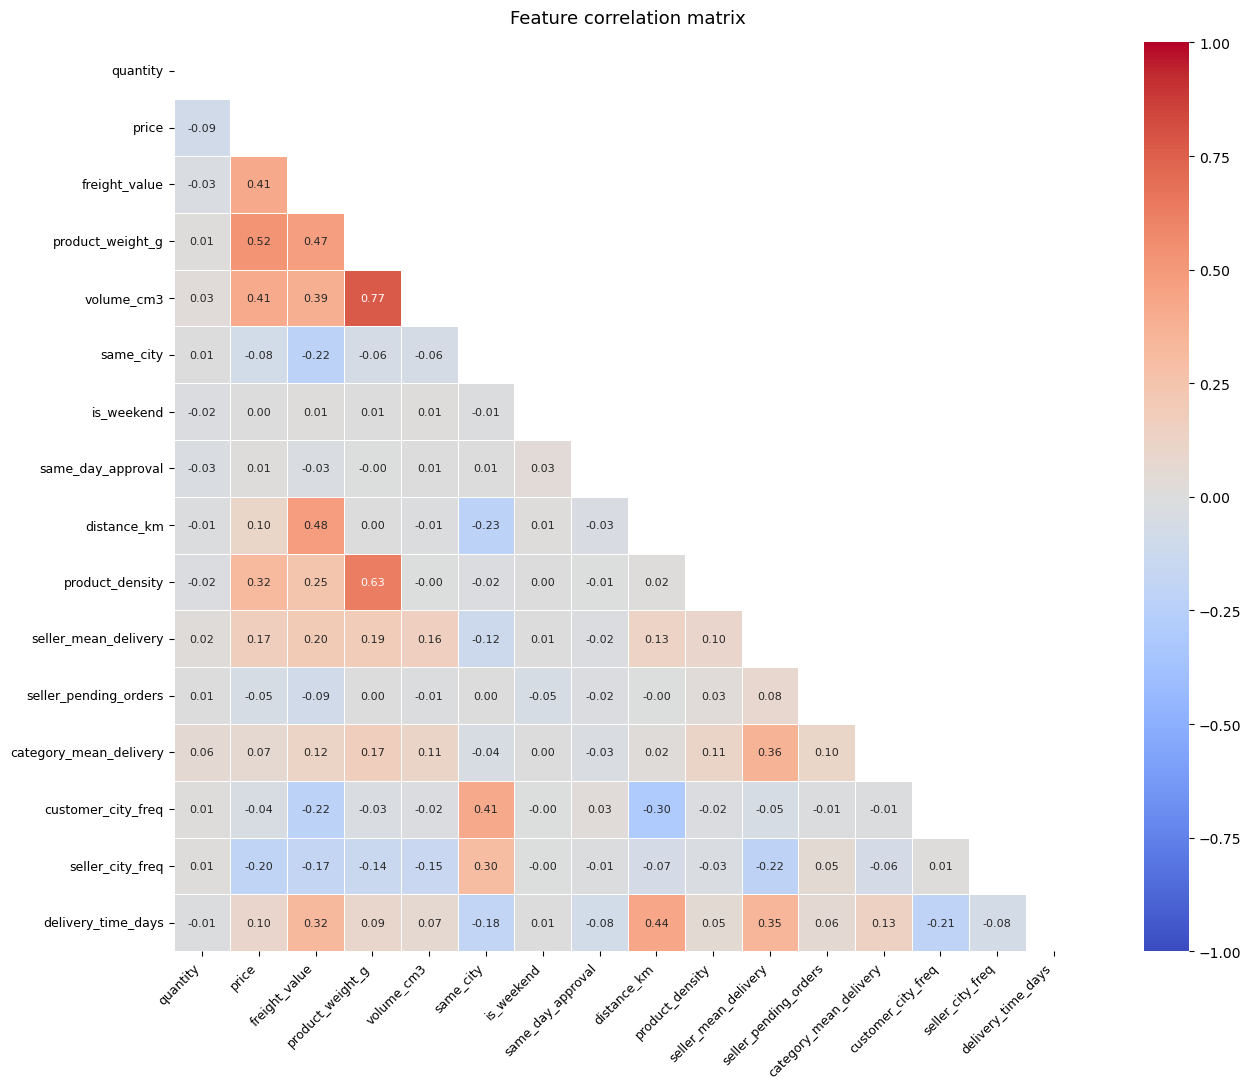

In [16]:
corr = train[feature_cols + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle only

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    square=True,
    ax=ax
)

ax.set_title('Feature correlation matrix', fontsize=13, pad=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('../plots/correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

# Correlations with target, sorted
print('\nCorrelations with target:')
display(
    corr[[TARGET]]
    .drop(TARGET)
    .sort_values(TARGET, ascending=False)
    .round(3)
)

---
## 12. Save

In [ ]:
import os
os.makedirs('dataset/processed', exist_ok=True)
os.makedirs('../plots', exist_ok=True)

train.to_csv('dataset/processed/train_features.csv', index=False)
test.to_csv( 'dataset/processed/test_features.csv',  index=False)

print('Saved train_features.csv ✓')
print('Saved test_features.csv  ✓')